In [19]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
csv_files = sorted(glob.glob("test_csvs/*.csv"))
print(f"Found {len(csv_files)} CSV files: {csv_files}")

Found 5 CSV files: ['test_csvs/10v_25e.csv', 'test_csvs/5v_6e.csv', 'test_csvs/7v_13e.csv', 'test_csvs/8v_21e.csv', 'test_csvs/9v_19e.csv']


Error reading CSV file test_csvs/10v_25e.csv: No columns to parse from file


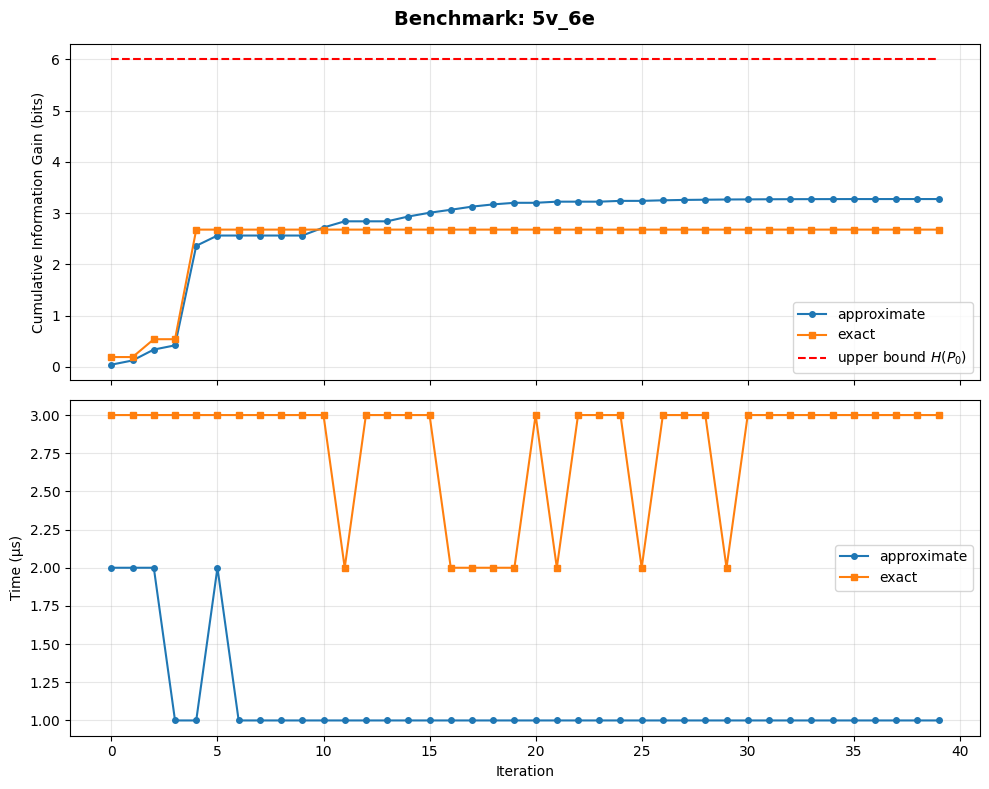

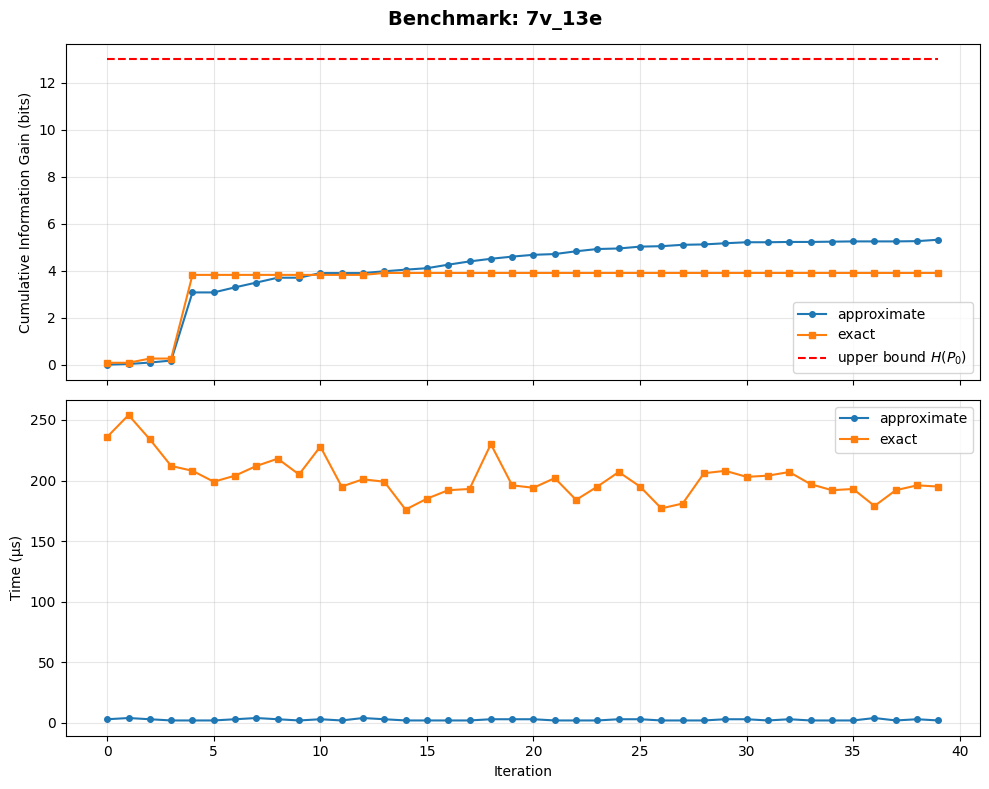

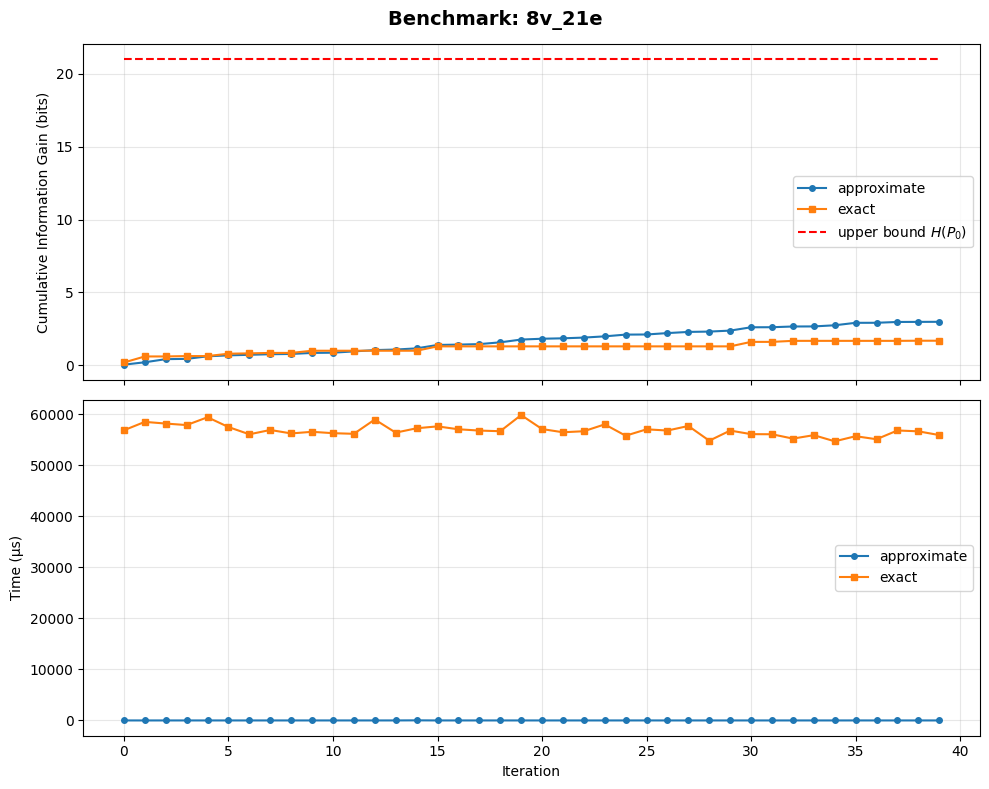

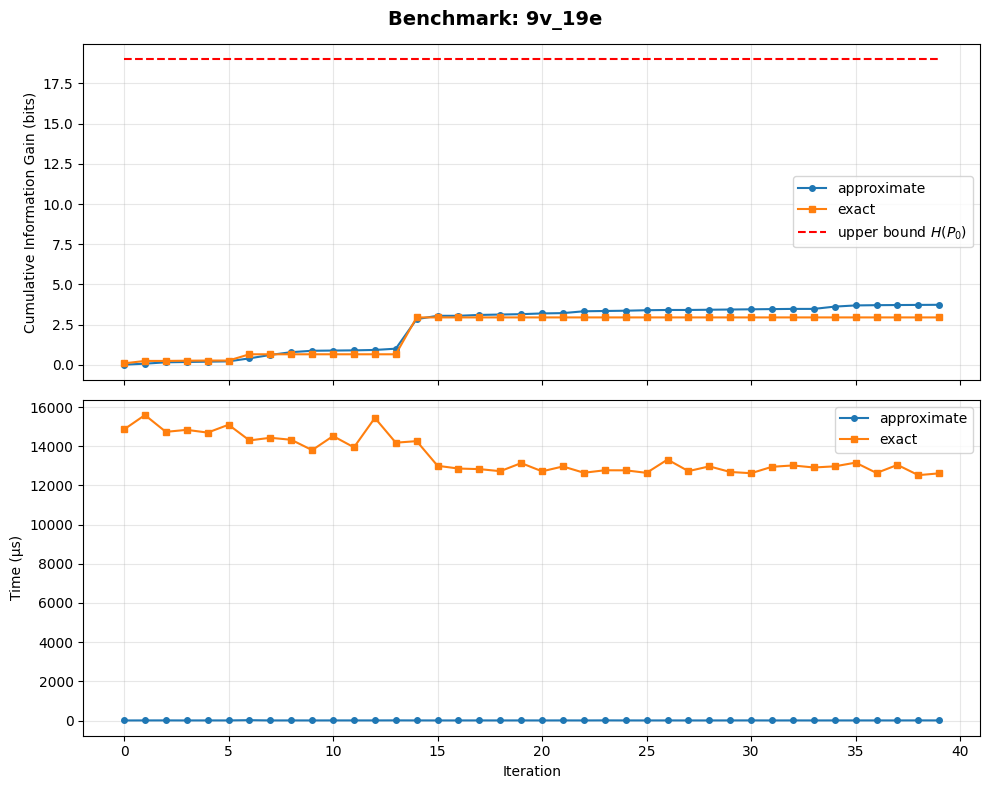

In [21]:
for csv_path in csv_files:
    # check make sure the csv is valid
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"Error reading CSV file {csv_path}: {e}")
        continue
    graph_name = csv_path.split("/")[-1].replace(".csv", "")

    approx = df[df["phase"] == "approximate"]
    exact = df[df["phase"] == "exact"]
    upper = df[df["phase"] == "upper_bound"]

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(f"Benchmark: {graph_name}", fontsize=14, fontweight="bold")

    # Information gain
    axes[0].plot(approx["iter"], approx["ig_bits"], marker="o", markersize=4, label="approximate")
    axes[0].plot(exact["iter"], exact["ig_bits"], marker="s", markersize=4, label="exact")
    if not upper.empty:
        axes[0].plot(upper["iter"], upper["ig_bits"], linestyle="--", color="red",
                     linewidth=1.5, label=r"upper bound $H(P_0)$")
    axes[0].set_ylabel("Cumulative Information Gain (bits)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Timing
    axes[1].plot(approx["iter"], approx["microseconds"], marker="o", markersize=4, label="approximate")
    axes[1].plot(exact["iter"], exact["microseconds"], marker="s", markersize=4, label="exact")
    axes[1].set_ylabel("Time (\u00b5s)")
    axes[1].set_xlabel("Iteration")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()